In [10]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import random
from sklearn.metrics import r2_score
import math
from sklearn.cluster import AgglomerativeClustering as ac
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
from sklearn.cluster import KMeans
import sys
import numpy.polynomial.polynomial as poly
from scipy.spatial import cKDTree
from scipy.ndimage import label
from PIL import Image
import copy
np.set_printoptions(threshold=sys.maxsize)

In [11]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [12]:
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('pics')
#for pic in pics:
#    plt.imshow(pic[...,::-1])
#    plt.show()

## Proof of Concept Steps based on Edge Detection

In [13]:
#Canny edge detection
img1 = pics[0].astype('uint8')
gray = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
edges = cv2.Canny(img1,100,200)
coord = np.array(np.where(edges != 0))
coord[[0, 1]] = coord[[1, 0]]
ind = random.sample(range(0, len(coord[0])), int(len(coord[0])/5))
points = (coord[0][ind], coord[1][ind])
points = np.array(points)
points = (points[0][np.argsort(points[1])], points[1][np.argsort(points[1])])
points = np.array(points)
#plt.scatter(points[0][0:20], points[1][0:20])
#plt.scatter(coord[0], coord[1], s=1)
oc_set = set() 
res = [] 
for idx, val in enumerate(points[0]): 
    if val not in oc_set: 
        oc_set.add(val)          
    else: 
        res.append(idx)
point = np.zeros(shape=(2,len(points[0])-len(res)))
point[0] = np.delete(points[0], res)
point[1] = np.delete(points[1], res)
coords = point.astype(int)
#coords

In [14]:
x = coords[0][0:20]
y = coords[1][0:20]
pol = np.poly1d(np.polyfit(x, y, 5))

xx = np.linspace(min(x),max(x), 100)
yy = np.polyval(pol,xx)  
pixels = zip(xx, yy)

#plt.plot(xx, yy, '-',x, y, 'ro')
#print(r2_score(y, pol(x)))

In [15]:
blank = pics[-1].copy()

In [16]:
'''
for x, y in pixels:
    blank[int(y)][int(x)][:] = 0
fig=plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(blank[...,::-1])
fig.add_subplot(1, 2, 2)
plt.imshow(pics[0][...,::-1])
plt.show()
'''

'\nfor x, y in pixels:\n    blank[int(y)][int(x)][:] = 0\nfig=plt.figure(figsize=(10, 10))\nfig.add_subplot(1, 2, 1)\nplt.imshow(blank[...,::-1])\nfig.add_subplot(1, 2, 2)\nplt.imshow(pics[0][...,::-1])\nplt.show()\n'

# Color Region Detection

## K Means for region detection

[581503375.0217717, 2701192.668337582, 763988.5080935261, 365752.06711753353, 223963.6140597192, 151414.37439153634, 118103.80905414041, 80631.58233001288, 64711.79298029555, 52061.601381458335, 45735.76321064328, 40039.447214447675, 33856.0922165614, 27584.01729964945, 23591.262665205068, 19975.101432902873, 19460.51442199327, 14703.1707727219, 13381.101268295337, 12243.376769907973]


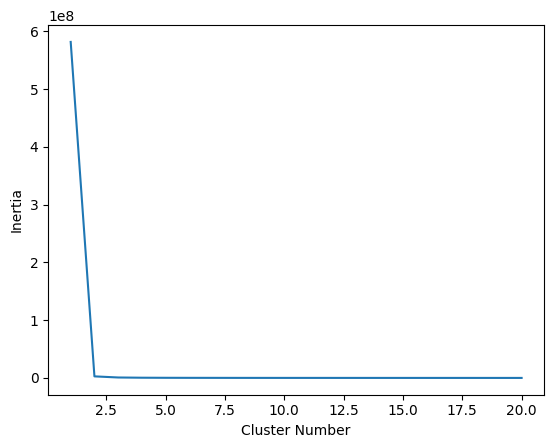

In [17]:
#Idea 1: K-Means clustering
#Problem is that it finds all pixels within a cluster but removes locality (ex. cluster contains two regions of green in
#different locations)

img1 = pics[0].astype('uint8')
img = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
img=img.reshape((img.shape[1]*img.shape[0],3))

md=[]
for i in range(1,21): #TODO Tuning parameter
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(img)
    o=kmeans.inertia_
    md.append(o)
print(md)

plt.plot(list(np.arange(1,21)),md) 
plt.xlabel("Cluster Number")
plt.ylabel("Inertia")
plt.show()
for i in range (0,len(md)):
    if md[i] < 2*md[i+1]: #TODO Tuning parameter
        nClusters = i-1
        break
#print(nClusters)

kmeans=KMeans(n_clusters=nClusters)
s=kmeans.fit(img)
labels=kmeans.labels_
centroid=kmeans.cluster_centers_
labels=list(labels)
percent=[]
for i in range(len(centroid)):
    j=labels.count(i)
    j=j/(len(labels))
    percent.append(j)
#plt.pie(percent,colors=np.array(centroid/255),labels=np.arange(len(centroid)))
#plt.show()


In [18]:
#plt.imshow(img1[...,::-1])
#plt.show()
pixLabels = np.array(labels).reshape((img1.shape[0],img1.shape[0]))

# Begin Compression

## Custom color region detection method

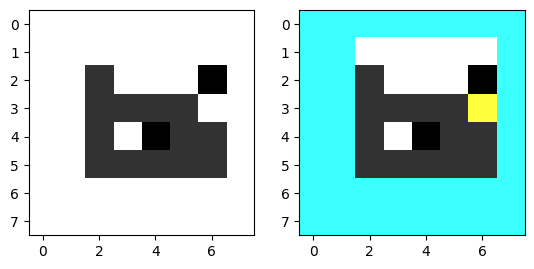

In [19]:
img1 = pics[-2].astype('uint8')
img1[2][2] = 50; img1[2][6] = 0; img1[3][2] = 50; img1[3][3] = 50; img1[3][4] = 50; img1[3][5] = 50; img1[4][2] = 50; img1[4][4] = 0
img1[4][5] = 50; img1[4][6] = 50; img1[5][2] = 50; img1[5][3] = 50; img1[5][4] = 50; img1[5][5] = 50; img1[5][6] = 50

img2 = pics[-2].astype('uint8')
img2[2][2] = 50; img2[2][6] = 0; img2[3][2] = 50; img2[3][3] = 50; img2[3][4] = 50; img2[3][5] = 50; img2[4][2] = 50; img2[4][4] = 0
img2[4][5] = 50; img2[4][6] = 50; img2[5][2] = 50; img2[5][3] = 50; img2[5][4] = 50; img2[5][5] = 50; img2[5][6] = 50
img2[0][0] = [255,255,60]; img2[0][1] = [255,255,60]; img2[0][2] = [255,255,60];   img2[0][3] = [255,255,60]; img2[0][4] = [255,255,60]
img2[0][5] = [255,255,60]; img2[0][6] = [255,255,60]; img2[0][7] = [255,255,60]; img2[7][0] = [255,255,60]; img2[7][1] = [255,255,60]
img2[7][2] = [255,255,60]; img2[7][3] = [255,255,60]; img2[7][4] = [255,255,60]; img2[7][5] = [255,255,60]; img2[7][6] = [255,255,60]
img2[7][7] = [255,255,60]; img2[1][0] = [255,255,60]; img2[2][0] = [255,255,60]; img2[3][0] = [255,255,60]; img2[4][0] = [255,255,60]
img2[5][0] = [255,255,60]; img2[6][0] = [255,255,60]; img2[1][7] = [255,255,60]; img2[2][7] = [255,255,60]; img2[3][7] = [255,255,60]
img2[4][7] = [255,255,60]; img2[5][7] = [255,255,60]; img2[6][7] = [255,255,60]; img2[1][1] = [255,255,60]; img2[2][1] = [255,255,60]
img2[3][1] = [255,255,60]; img2[4][1] = [255,255,60]; img2[5][1] = [255,255,60]; img2[6][1] = [255,255,60]; img2[6][2] = [255,255,60]
img2[6][3] = [255,255,60]; img2[6][4] = [255,255,60]; img2[6][5] = [255,255,60]; img2[6][6] = [255,255,60]; img2[6][7] = [255,255,60]
img2[3][6] = [60,255,255]
f, axarr = plt.subplots(1,2)
axarr[0].imshow(img1[...,::-1])
axarr[1].imshow(img2[...,::-1])

## Save image as png and jpeg

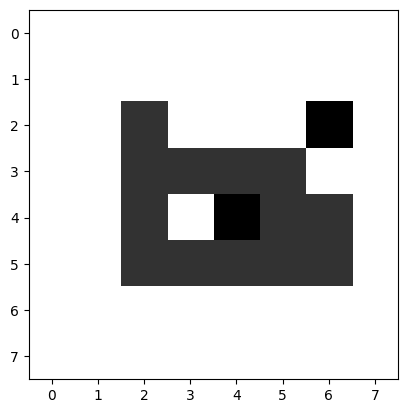

In [20]:
chosenImage = img1
im = Image.fromarray(chosenImage)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

## Detect color regions and cluster

In [21]:
def checkFit(p1, p2):
    d=math.sqrt((np.rint(np.mean(p1[0])).astype(int)-p2[0])**2+
                            (np.rint(np.mean(p1[1])).astype(int)-p2[1])**2+
                            (np.rint(np.mean(p1[2])).astype(int)-p2[2])**2)
    p=d/math.sqrt((255)**2+(255)**2+(255)**2)
    return p

In [22]:
#Recursive function for each pixel that matches the cluster value, explore to see if it can get back to
#a visited pixel in the same cluster
#To allow diagonal escape, uncomment recursive lines
def findHome(startX, startY, i, j, img1, imgClusters, visited, clusterNum, cMean, finds):
    if i > img1.shape[0]-1 or i < 0 or j > img1.shape[0]-1 or j < 0:
        finds.append(1)
        return
    searched[i][j] = 0
    if (i == startX and j == startY) or (visited[i][j] == 0 and (checkFit(cMean, img1[i][j]) <= thresh)):
        finds.append(2)
        return
    if visited[i][j] != 0 and (checkFit(cMean, img1[i][j]) > thresh):
        finds.append(3)
        return
    if visited[i][j] != 0 and (checkFit(cMean, img1[i][j]) <= thresh):
        finds.append(4)
        #if not (i-1 > img1.shape[0]-1 or i-1 < 0 or j-1 > img1.shape[0]-1 or j-1 < 0):
        #    if searched[i-1][j-1] != 0:
                #findHome(startX, startY, i-1, j-1, img1, imgClusters, visited, clusterNum, cMean, finds)
        if not (i > img1.shape[0]-1 or i < 0 or j-1 > img1.shape[0]-1 or j-1 < 0):
            if searched[i][j-1] != 0:
                findHome(startX, startY, i, j-1, img1, imgClusters, visited, clusterNum, cMean, finds)
        #if not (i+1 > img1.shape[0]-1 or i+1 < 0 or j-1 > img1.shape[0]-1 or j-1 < 0):
        #    if searched[i+1][j-1] != 0:
                #findHome(startX, startY, i+1, j-1, img1, imgClusters, visited, clusterNum, cMean, finds)
        if not (i-1 > img1.shape[0]-1 or i-1 < 0 or j > img1.shape[0]-1 or j < 0):
            if searched[i-1][j] != 0:
                findHome(startX, startY, i-1, j, img1, imgClusters, visited, clusterNum, cMean, finds)
        if not (i+1 > img1.shape[0]-1 or i+1 < 0 or j > img1.shape[0]-1 or j < 0):
            if searched[i+1][j] != 0:
                findHome(startX, startY, i+1, j, img1, imgClusters, visited, clusterNum, cMean, finds)
        #if not (i-1 > img1.shape[0]-1 or i-1 < 0 or j+1 > img1.shape[0]-1 or j+1 < 0):
        #    if searched[i-1][j+1] != 0:
                #findHome(startX, startY, i-1, j+1, img1, imgClusters, visited, clusterNum, cMean, finds)
        if not (i > img1.shape[0]-1 or i < 0 or j+1 > img1.shape[0]-1 or j+1 < 0):
            if searched[i][j+1] != 0:
                findHome(startX, startY, i, j+1, img1, imgClusters, visited, clusterNum, cMean, finds)
        #if not (i+1 > img1.shape[0]-1 or i+1 < 0 or j+1 > img1.shape[0]-1 or j+1 < 0):
        #    if searched[i+1][j+1] != 0:
                #findHome(startX, startY, i+1, j+1, img1, imgClusters, visited, clusterNum, cMean, finds)
    return

In [23]:
#Idea 2: Keep track of average color within a region as I search for extent of a region and compare new pixel with average 
#rather than adjacent pixel and if it is added, adjust the average, if not draw boundary
#Make greedy assumption each iteration of a cluster that every remaining pixel is in that cluster until proven otherwise
#This is key for finding middle pixels
#img1 = pics[1].astype('uint8')    
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

imgClusters = np.ones((img1.shape[0], img1.shape[1])).astype(int) #Matrix where each coord indicates its cluster (i,j) = cluster number
clusterEdges = [] #Clusters by perimeter matrix, gives the perimeter coordinates of every cluster
visited = np.ones((img1.shape[0], img1.shape[1])).astype(int) #Matrix if coord is 0, it has been added to a cluster, 1 has not gained membership
clusterNum = 1 #Current cluster number
clustMeans = []

thresh = 0.05

#print(img, thresh, percentMerge)

while np.count_nonzero(visited) > 0:
    firstFind = 0
    #Set all unvisited pixels to current cluster value
    imgClusters[visited != 0] = clusterNum
    for i in range(0,img.shape[0]):
        for j in range(0,img.shape[1]):
            if visited[i][j] == 1:
                if firstFind == 0:
                    startX = i
                    startY = j
                    cMean = [[],[],[]] #Mean of the current cluster
                    clust = [] #Border pixels of current cluster
                    cMean[0].append(img[i][j][0])
                    cMean[1].append(img[i][j][1])
                    cMean[2].append(img[i][j][2])
                    firstFind = 1
                p = checkFit(cMean, img[i][j])

                #IF the current pixel is in the cluster
                if p < thresh: 
                    #Look for holes
                    reachable = False
                    searched = np.ones((img1.shape[0], img1.shape[1])).astype(int)
                    finds = []
                    findHome(startX, startY, i, j, img, imgClusters, visited, clusterNum, cMean, finds)
                    if (2 in finds or 1 in finds):
                        reachable = True
                    if reachable:
                        visited[i][j] = 0 #Mark it as visited
                        imgClusters[i][j] = clusterNum #Assign it to current cluster
                        cMean[0].append(img[i][j][0]) #Adjust the mean cluster value
                        cMean[1].append(img[i][j][1])
                        cMean[2].append(img[i][j][2])

                        #IF the current pixel is an absolute border pixel
                        if i+1 > img1.shape[0]-1 or i-1 < 0 or j+1 > img1.shape[0]-1 or j-1 < 0:
                            clust.append((i,j))

                        #IF the current pixel is not on the absolute border
                        else:
                            #IF any neighbors are in a different cluster, add current pixel to border
                            r1 = -1
                            r2 = -1
                            addPix = False
                            for m in range(0,3):
                                for n in range(0,3):
                                    if (checkFit(cMean, img[i+r1+m][j+r2+n]) > thresh):
                                        addPix = True
                            if addPix:
                                clust.append((i,j))
    clusterNum += 1
    clusterEdges.append(list(set(clust)))
    clustMeans.append((np.rint(np.mean(cMean[0])).astype(int), np.rint(np.mean(cMean[1])).astype(int), np.rint(np.mean(cMean[2])).astype(int)))

In [24]:
#Percent merge function
percentMerge = 0.01
rowsToDelete = []
for i in range(0, len(clusterEdges)):
    if (len(clusterEdges[i])/(img1.shape[0]*img1.shape[1])) < percentMerge:
        for coord in clusterEdges[i]:
            #Find closest point
            closest = 1000
            clustJoin = -1
            for j in range(0,len(clusterEdges)):
                if j == i:
                    continue
                for k in range(0, len(clusterEdges[j])):
                    dist = math.dist(coord, clusterEdges[j][k])
                    if dist < closest:
                        closest = dist
                        clustJoin = j
            #add point's to closest points cluster 
            imgClusters[coord] = clustJoin+1
            
            #determine if new point is border pixel and add if so
            r1 = -1
            r2 = -1
            addPix = False
            for m in range(0,3):
                for n in range(0,3):
                    if (imgClusters[i+r1+m][j+r2+n] != clustJoin):
                        addPix = True
            if addPix:
                clusterEdges[clustJoin].append(coord)
                
            #delete row and its mean
            rowsToDelete.append(i)
rowsToDelete = sorted(rowsToDelete, reverse=True)
for row in rowsToDelete:
    del clusterEdges[row]
    del clustMeans[row]

In [25]:
imgClusters

array([[1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 2, 1, 1, 1, 3, 1],
       [1, 1, 2, 2, 2, 2, 1, 1],
       [1, 1, 2, 4, 5, 2, 2, 1],
       [1, 1, 2, 2, 2, 2, 2, 1],
       [1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1]])

## Sort the clusters

In [26]:
def sortClusters(visited, edgesSorted, x, y):
    curX = 0
    curY = 0
    inertia = -1
    hops = 0
    
    #find min coord, prioritizes min y first then x
    unvisited = [j for j in range(len(visited[i])) if visited[i][j] == 0]
    availMin = [clusterEdges[i][j] for j in unvisited]
    if len(availMin) < 1:
        return edgesSorted
    curX = min(availMin)[0]
    curY = min(availMin)[1]
    homeX = curX
    homeY = curY
    curIndex = clusterEdges[i].index((curX, curY))
    
    #add to outer, mark visited
    edgesSorted[i][0].append(curX)
    edgesSorted[i][1].append(curY)
    visited[i][curIndex] = 1
    
    if (curX+1, curY) in clusterEdges[i] and visited[i][clusterEdges[i].index((curX+1, curY))] != 1:
        inertia = 1
    elif (curX, curY+1) in clusterEdges[i] and visited[i][clusterEdges[i].index((curX, curY+1))] != 1:
        inertia = 2
    elif (curX-1, curY) in clusterEdges[i] and visited[i][clusterEdges[i].index((curX-1, curY))] != 1:
        inertia = 3
    elif (curX, curY-1) in clusterEdges[i] and visited[i][clusterEdges[i].index((curX, curY-1))] != 1:
        inertia = 4
        
    #curX, curY, homeX, homeY, curIndex, inertia
    while (visited[i].count(0) > 0) and (not ((curX+1 == homeX and curY == homeY) or (curX-1 == homeX and curY == homeY) or 
                                         (curX == homeX and curY+1 == homeY) or (curX == homeX and curY-1 == homeY)) and 
                                         inertia != -1 or hops < 2):
        #print("Starting position:", (curX, curY), '\nStarting inertia:', inertia)
        
        down = (curX+1, curY) in clusterEdges[i]
        right = (curX, curY+1) in clusterEdges[i]
        up = (curX-1, curY) in clusterEdges[i]
        left = (curX, curY-1) in clusterEdges[i]
                
        skippable = False
        #if theres only one option
        if not down and not right and not up:
            inertia = 4
            skippable = True
        if not right and not up and not left:
            inertia = 1
            skippable = True
        if not up and not left and not down:
            inertia = 2
            skippable = True
        if not left and not down and not right:
            inertia = 3
            skippable = True
        
        #if going in direction and can keep going in direction with unvisited
        if inertia == 1 and down and visited[i][clusterEdges[i].index((curX+1, curY))] != 1:
            skippable = True
        elif inertia == 2 and right and visited[i][clusterEdges[i].index((curX, curY+1))] != 1:
            skippable = True
        elif inertia == 3 and up and visited[i][clusterEdges[i].index((curX-1, curY))] != 1:
            skippable = True
        elif inertia == 4 and left and visited[i][clusterEdges[i].index((curX, curY-1))] != 1:
            skippable = True
        
        if not skippable:
            moveable = False
            possibleDirs = []
            if down:
                #print("dir 1 to ", (curX+1, curY))
                possibleDirs.append(1)
                if visited[i][clusterEdges[i].index((curX+1, curY))] != 1:
                    inertia = 1
                    moveable = True
            if right:
                #print("dir 2 to ", (curX, curY+1))
                possibleDirs.append(2)
                if visited[i][clusterEdges[i].index((curX, curY+1))] != 1:
                    inertia = 2
                    moveable = True
            if up:
                #print("dir 3 to ", (curX-1, curY))
                possibleDirs.append(3)
                if visited[i][clusterEdges[i].index((curX-1, curY))] != 1:
                    inertia = 3
                    moveable = True
            if left:
                #print("dir 4 to ", (curX, curY-1))
                possibleDirs.append(4)
                if visited[i][clusterEdges[i].index((curX, curY-1))] != 1:
                    inertia = 4
                    moveable = True
            #print("Middle inertia:", inertia, "\nMiddle Moveable:",moveable)
            #continue inertia if possible
            if not moveable:
                #all neighbors visited but inertia is possible wait
                if inertia not in possibleDirs:
                    #all neighbors visited but inertia not possible
                    unvisited = [j for j in range(len(visited[i])) if visited[i][j] == 0]
                    availMin = [clusterEdges[i][j] for j in unvisited]
                    oneCount = sum(j[0] > curX for j in availMin)
                    twoCount = sum(j[1] > curY for j in availMin)
                    threeCount = sum(j[0] < curX for j in availMin)
                    fourCount = sum(j[1] < curY for j in availMin)
                    #find available direction with most unvisited and move that way
                    #if theres a tie, it prioritizes min y then x, make it have tendency to not retrace unless necessary
                    l = [oneCount,twoCount,threeCount,fourCount]
                    m = [i+1 for i, x in enumerate(l) if x == max(l)]
                    wrongDir = 0
                    if inertia+2 in m:
                        wrongDir = (m.index(inertia+2)+3)
                    elif inertia-2 in m:
                        wrongDir = (m.index(inertia-2)+1)
                    inertia = [x for x in m if wrongDir != x][0]
        if inertia == 1:
            curX+=1
        elif inertia == 2:
            curY+=1
        elif inertia == 3:
            curX-=1
        elif inertia == 4:
            curY-=1
        #print("Ending Position:", (curX, curY), '\nEnding Inertia:', inertia, "\n")
        if not ((visited[i].count(0) > 0) and (not ((curX+1 == homeX and curY == homeY) or (curX-1 == homeX and curY == homeY) or 
                                         (curX == homeX and curY+1 == homeY) or (curX == homeX and curY-1 == homeY)) and 
                                         inertia != -1 or hops < 2)):
            return edgesSorted
        curIndex = clusterEdges[i].index((curX, curY))
        edgesSorted[i][x].append(curX)
        edgesSorted[i][y].append(curY)
        visited[i][curIndex] = 1
        hops += 1
    return edgesSorted

In [27]:
#Search through image clusters and move in same direction until not possible then move in other direction to form trace
edgesSorted = [None]*len(clusterEdges)
for i in range(0,len(edgesSorted)):
    edgesSorted[i] = [[],[],[],[]]
visited = copy.deepcopy(clusterEdges)
for i in range (0,len(visited)):
    for j in range (0, len(visited[i])):
        visited[i][j] = 0

#Visited, edgesSorted, clusterEdges
for i in range(0, len(clusterEdges)):
    #Outer
    edgesSorted = sortClusters(visited, edgesSorted, 0, 1)
    #Inner
    edgesSorted = sortClusters(visited, edgesSorted, 2, 3)

## Segment sorted clusters into piecewise polynomials

In [28]:
#Fit to polynomial
def polyFit(x,y):
    y = np.array(y)
    x = np.array(x)
    #print(x, y)
    for i in range(0,21):
        pol = np.poly1d(np.polyfit(x, y, i))
        test = pol(x).astype(int)
        #print("Res:", r2_score(y, pol(x)))
        if r2_score(y, pol(x)) > 0.9:
            #print("here", r2_score(y, pol(x)), pol.c)
            #print(pol(x), y)
            return pol.c

In [29]:
#clustMeans, edgesSorted
percentSkip = 0.1
f = open("imComp.txt", "a")
for i in range(0,len(edgesSorted)):
    f.write("C;" + str(clustMeans[i][0]) + ',' + str(clustMeans[i][1]) + ',' + str(clustMeans[i][2]) + ';\n')
    l = [[],[]]
    vert = [[],[]]
    track = -1
    for j in range(0,len(edgesSorted[0]), 2):
        clustSize = len(edgesSorted[i][j])
        skipInterval = round(clustSize*percentSkip)
        if skipInterval == 0:
            skipInterval = 1
        for k in range(0, len(edgesSorted[i][j]), skipInterval):
            x = edgesSorted[i][j][k]
            y = edgesSorted[i][j+1][k]
            if (k+1 == len(edgesSorted[i][j])):
                saveX = edgesSorted[i][j][k]
                saveY = edgesSorted[i][j+1][k]
            if x not in l[0]:
                if track == 1:
                    f.write("V;" + str(vert[0][0]) + ',' + str(vert[1][0]) + ';' + str(vert[0][-1]) + ',' + str(vert[1][-1]) + ';\n')
                vert = [[],[]]
                track = 0
            else:
                if track == 0:
                    coefs = polyFit(l[0], l[1])
                    poly = ''
                    for m in range(0, len(coefs)):
                        if m+1 == len(coefs):
                            poly = poly + str(coefs[m])
                        else:
                            poly = poly + str(coefs[m]) + ','
                    f.write("P;" + str(l[0][0]) + ';' + str(poly) + ';' + str(l[0][-1]) + ';\n')
                l = [[],[]]
                track = 1
            vert[0].append(x)
            vert[1].append(y)
            l[0].append(x)
            l[1].append(y)
        f.write(".\n")
    f.write("E;" + str(saveX) + ',' + str(saveY) + ';\n\n')
f.close()

## Save equations to file, compression complete

In [30]:
#Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 557
JPEG compress: 667
PNG compress: 118
Tiff compress: 332


# Begin Decompression

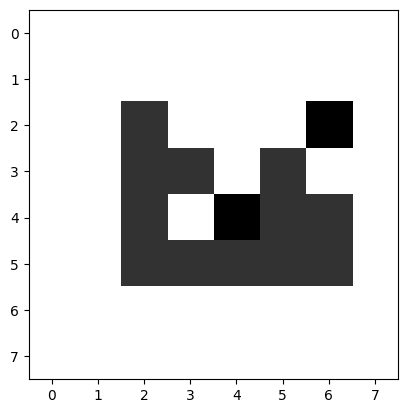

In [31]:
#read from file
colored = np.ones((img1.shape[0], img1.shape[1])).astype(int)
imRecover = pics[-2].astype('uint8')
maxVal = imRecover.shape[0]-1
minVal = 0
f = open("imComp.txt", "r")
c = 0
for line in f:
    l = line.split(';')
    if 'C' in l[0]:
        avgCol = l[1].split(',')
        avgCol = np.array([[[np.uint8(i) for i in avgCol]]])
        avgCol = cv2.cvtColor(avgCol, cv2.COLOR_HSV2BGR)
        c = 1
    if 'P' in l[0]:
        startPt = l[1]
        poly = l[2].split(',')
        poly = [float(i) for i in poly]
        p = np.poly1d(poly)
        endPt = l[3]
        x = list(range(int(min(startPt, endPt)), int(max(startPt, endPt))+1))
        y = []
        for i in p(x):
            v = round(i)
            if v > maxVal:
                v = maxVal
            if v < minVal:
                v = minVal
            y.append(v)
        for i,j in zip(x,y):
            imRecover[i][j] = avgCol
            colored[i][j] = 0
        c = 0
        #print(x, y)
    if 'V' in l[0]:
        startPt = l[1].split(',')
        endPt = l[2].split(',')
        size = int(max(startPt[1], endPt[1]))-int(min(startPt[1], endPt[1]))
        x = [int(startPt[0])]*(size+1)
        y = list(range(int(min(startPt[1], endPt[1])), int(max(startPt[1], endPt[1]))+1))
        c = 0
        for i,j in zip(x,y):
            imRecover[i][j] = avgCol
            colored[i][j] = 0
        #imRecover[x][y] = avgCol
    if 'E' in l[0]:
        pt = l[1].split(',')
        imRecover[int(pt[0])][int(pt[1])] = avgCol
        colored[int(pt[0])][int(pt[1])] = 0
    #print(avgCol)
plt.imshow(imRecover)
plt.show()

In [32]:
colored

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 1, 1, 1, 0, 1],
       [1, 0, 0, 1, 1, 0, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 1, 0],
       [1, 1, 0, 0, 0, 0, 1, 1]])

In [33]:
#Fill in the gaps outlined by border pixels
for i in range(0, len(colored)):
    for j in range(0, len(colored[i])):
        if colored[i][j] == 1:
            r1 = -1
            r2 = -1
            neighborColors = []
            for m in range(0,3):
                for n in range(0,3):
                    if not (i+r1+m > img1.shape[0]-1 or i+r1+m < 0 or j+r2+n > img1.shape[0]-1 or j+r2+n < 0):
                        if (colored[i+r1+m][j+r2+n] == 0):
                            neighborColors.append(imRecover[i+r1+m][j+r2+n])
            neighborColors = [tuple(k.tolist()) for k in neighborColors]
            newColor = max(set(neighborColors), key=neighborColors.count)
            imRecover[i][j] = newColor
            colored[i][j] = 0

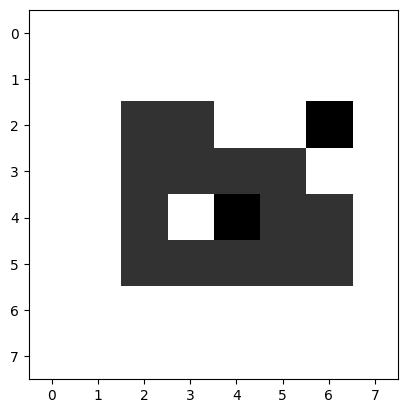

In [34]:
plt.imshow(imRecover)
plt.show()

In [35]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')

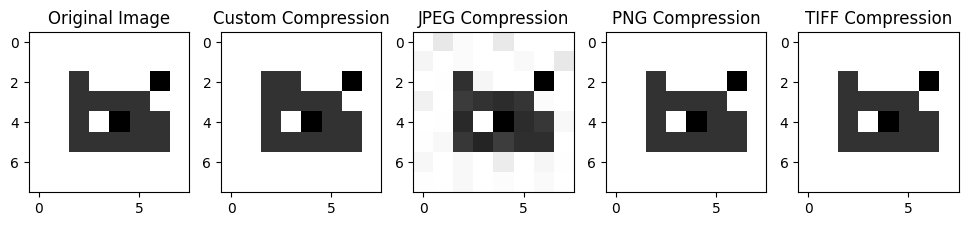

In [36]:
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(img1[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(imRecover[...,::-1])
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])
axarr[4].title.set_text('TIFF Compression')